# ETL del dataset AI-SOCO

En esta notebook, realizamos un proceso de ETL, en donde unimos cada código fuente con sus respectivos identificadores y limpiamos el código, eliminando caracteres que no se puedan reconocer. Además, realizamos un análisis exploratorio de datos para entender mejor la estructura y contenido del dataset.


Extraer los archivos del dataset SOCO

In [40]:
import re
import gc
import random
import pyarrow
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.model_selection import train_test_split

In [29]:
# Constantes y rutas
SEED = 42
TRAIN_PATH = "AI-SOCO-master/data_dir/train"
DEV_PATH = "AI-SOCO-master/data_dir/dev"
TEST_PATH = "AI-SOCO-master/data_dir/test"


sacar iso uid y pid 

In [30]:
train_csv = "AI-SOCO-master/data_dir/train.csv"
test_csv = "AI-SOCO-master/data_dir/unlabeled_test.csv"
dev_csv = "AI-SOCO-master/data_dir/dev.csv"

train_df = pd.read_csv(train_csv)
test_df = pd.read_csv(test_csv)
dev_df = pd.read_csv(dev_csv)



In [31]:
# Cargar los códigos fuente para train
for index, row in train_df.iterrows():
    train_df.loc[index, 'code'] = open(f"{TRAIN_PATH}/{row['pid']}", encoding='utf-8').read()

In [32]:
# Cargar los códigos fuente para dev
for index, row in dev_df.iterrows():
    dev_df.loc[index, 'code'] = open(f"{DEV_PATH}/{row['pid']}", encoding='utf-8').read()

In [33]:
# Cargar los códigos fuente para test (unlabeled_test sin uid)
for index, row in test_df.iterrows():
    test_df.loc[index, 'code'] = open(f"{TEST_PATH}/{int(row['pid'])}", encoding='utf-8', errors='ignore').read()

## Análisis exploratorio de datos

Antes de hacer cualquier modificación, sacamos estadísticas básicas e información de los datasets para entender su estructura y contenido, como el número de registros, tipos de datos, valores nulos, etc. 


In [39]:
# Calcular métricas derivadas del código fuente
for df in [train_df, dev_df]:
    df['code_len']   = df['code'].str.len()
    df['line_count'] = df['code'].str.count('\n') + 1
    
print("Primeras filas de train_df:")
print(train_df.head(), "\n")
print(train_df.info(), "\n")

print("Primeras filas de dev_df:")
print(dev_df.head(), "\n")
print(dev_df.info(), "\n")

print("Primeras filas de test_df:")
print(test_df.head(), "\n")
print(test_df.info(), "\n")

# -------------- Balance por autor ---------------------
subs = train_df.groupby('uid')['pid'].count()
print(f"\nBalance por autor en train_df:")
print(f"Minimo: {subs.min()}  Máximo: {subs.max()})")

# -------------- Solapamiento entre splits -------------
print("\n Solapamiento entre splits")
print(f" UIDs train en y dev: {len(set(train_df['uid']) & set(dev_df['uid'])):,}")
print(f" PIDs train en y dev: {len(set(train_df['pid']) & set(dev_df['pid'])):,} ")
print(f" PIDs train en y test: {len(set(train_df['pid']) & set(test_df['pid'])):,}")

# -------------- Estadísticas de longitud --------------
print("\n Longitud del código fuente (medido en caracteres)")
for df, name in [(train_df, 'Train'), (dev_df, 'Dev')]:
    d = df['code_len']
    print(f"  {name}: media={d.mean():.0f}  mediana={d.median():.0f}  "
          f"min={d.min():.0f}  max={d.max():.0f}  std={d.std():.0f}")
print("\n Líneas de código")
for df, name in [(train_df, 'Train'), (dev_df, 'Dev')]:
    d = df['line_count']
    print(f"  {name}: media={d.mean():.1f}  mediana={d.median():.0f}  "
          f"min={d.min():.0f}  max={d.max():.0f}")

Primeras filas de train_df:
   uid    pid                                               code  code_len  \
0  415  27909  /*{{{*/\n#include<cstdio>\n#include<cstdlib>\n...      4144   
1  415  55938  /*{{{*/\n#include<cstdio>\n#include<cstdlib>\n...      2840   
2  415  90936  /*{{{*/\n#include<cstdio>\n#include<cstdlib>\n...      2762   
3  415  56858  /*{{{*/\n#include<cstdio>\n#include<cstdlib>\n...      3094   
4  415   9447  /*{{{*/\n#include<cstdio>\n#include<cstdlib>\n...      2603   

   line_count  
0         158  
1          90  
2          94  
3         105  
4          83   

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   uid         50000 non-null  int64
 1   pid         50000 non-null  int64
 2   code        50000 non-null  str  
 3   code_len    50000 non-null  int64
 4   line_count  50000 non-null  int64
dtypes: int64(4), str(1)
memory usa

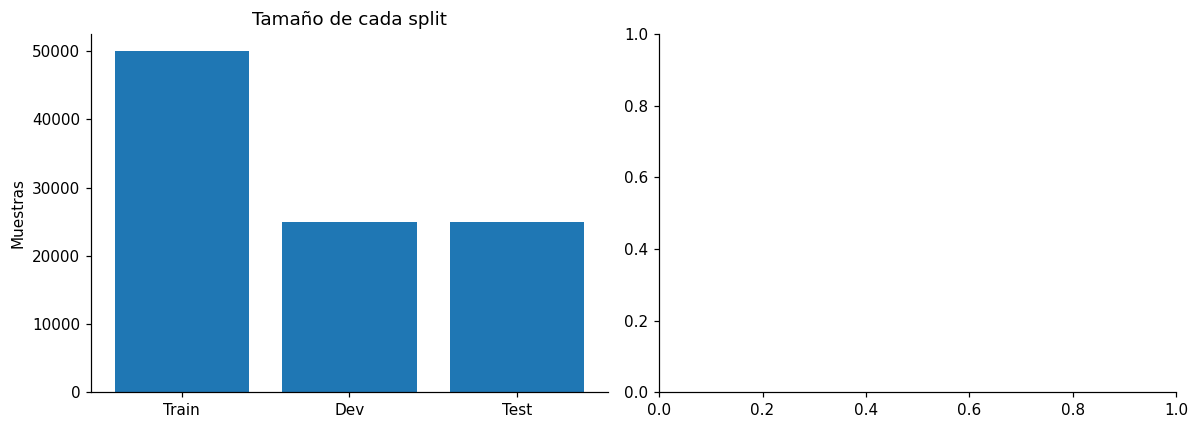

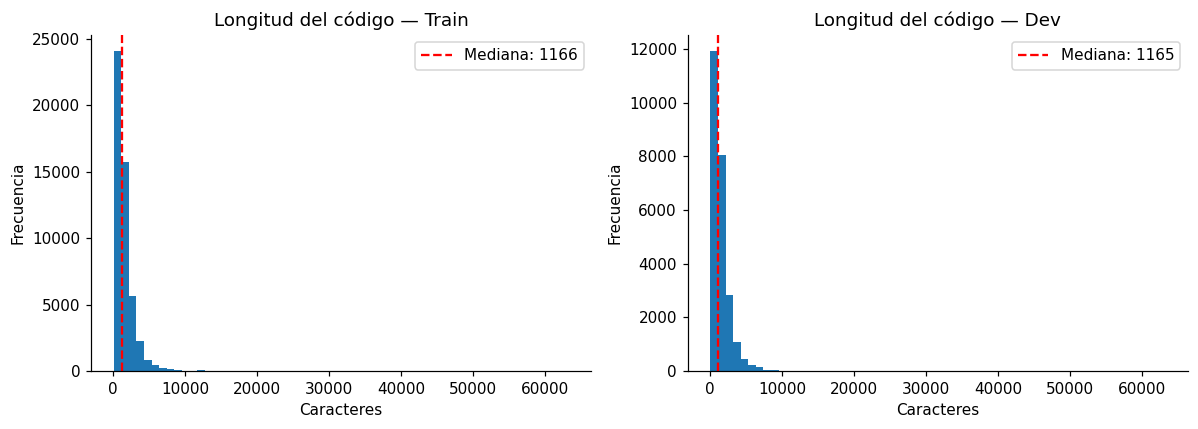

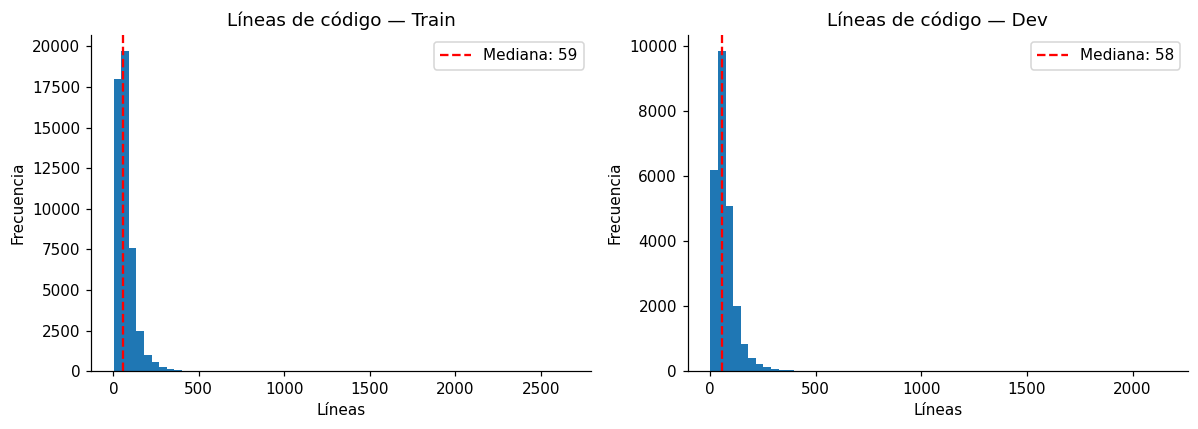

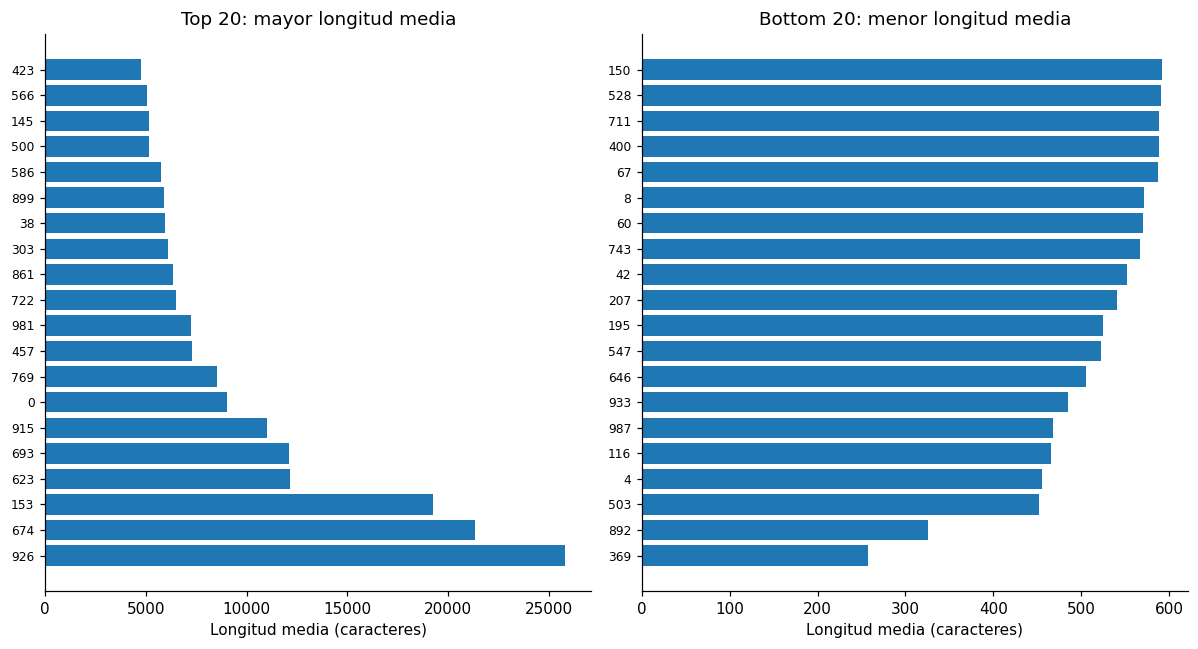

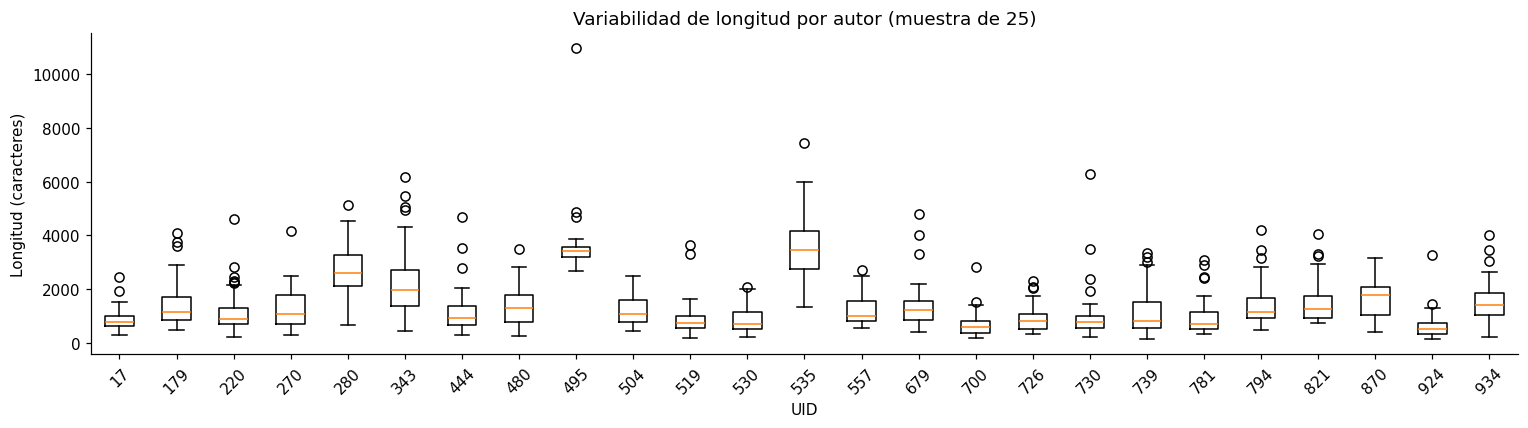

In [42]:
# 1. Tamaño de cada split y envíos por autor
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

splits = ['Train', 'Dev', 'Test']
counts = [len(train_df), len(dev_df), len(test_df)]
axes[0].bar(splits, counts)
axes[0].set_title('Tamaño de cada split')
axes[0].set_ylabel('Muestras')

plt.tight_layout()
plt.show()

# 2. Distribución de longitud de código
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, df, name in zip(axes, [train_df, dev_df], ['Train', 'Dev']):
    ax.hist(df['code_len'], bins=60)
    ax.axvline(df['code_len'].median(), color='red', linestyle='--',
               label=f'Mediana: {df["code_len"].median():.0f}')
    ax.set_title(f'Longitud del código — {name}')
    ax.set_xlabel('Caracteres')
    ax.set_ylabel('Frecuencia')
    ax.legend()

plt.tight_layout()
plt.show()

# 3. Distribución de líneas de código
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, df, name in zip(axes, [train_df, dev_df], ['Train', 'Dev']):
    ax.hist(df['line_count'], bins=60)
    ax.axvline(df['line_count'].median(), color='red', linestyle='--',
               label=f'Mediana: {df["line_count"].median():.0f}')
    ax.set_title(f'Líneas de código — {name}')
    ax.set_xlabel('Líneas')
    ax.set_ylabel('Frecuencia')
    ax.legend()

plt.tight_layout()
plt.show()

# 4. Top/Bottom 20 autores por longitud media
author_mean = train_df.groupby('uid')['code_len'].mean().sort_values(ascending=False)
n = 20
fig, axes = plt.subplots(1, 2, figsize=(11, 6))

for ax, series, title in zip(
    axes,
    [author_mean.head(n), author_mean.tail(n).iloc[::-1]],
    [f'Top {n}: mayor longitud media', f'Bottom {n}: menor longitud media']
):
    ax.barh(range(n), series.values)
    ax.set_yticks(range(n))
    ax.set_yticklabels(series.index.astype(str), fontsize=8)
    ax.set_xlabel('Longitud media (caracteres)')
    ax.set_title(title)

plt.tight_layout()
plt.show()

# 5. Variabilidad por autor — box plot (muestra de 25)

random.seed(42)
sample_uids = sorted(random.sample(list(train_df['uid'].unique()), 25))
sample_data = train_df[train_df['uid'].isin(sample_uids)]
groups = [grp['code_len'].values for _, grp in sample_data.groupby('uid')]
labels = [str(uid) for uid, _ in sample_data.groupby('uid')]

fig, ax = plt.subplots(figsize=(14, 4))
ax.boxplot(groups, tick_labels=labels)
ax.set_title('Variabilidad de longitud por autor (muestra de 25)')
ax.set_xlabel('UID')
ax.set_ylabel('Longitud (caracteres)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [36]:
# Función de Limpieza de código
def clean_code(code):
    # Eliminar caracteres no pertenecientes a UTF-8
    code = code.encode('utf-8', errors='ignore').decode('utf-8')
    return code

In [37]:
# Aplicar limpieza al código fuente
train_df['code'] = train_df['code'].apply(clean_code)
dev_df['code'] = dev_df['code'].apply(clean_code)
test_df['code'] = test_df['code'].apply(clean_code)
print("Limpieza aplicada a todos los conjuntos de datos")

Limpieza aplicada a todos los conjuntos de datos


In [38]:
# Guardar todos en Parquet (más eficiente que CSV)
train_df.to_parquet("train_processed.parquet", index=False)
dev_df.to_parquet("dev_processed.parquet", index=False)
test_df.to_parquet("test_processed.parquet", index=False)

print("Archivos Parquet creados exitosamente:")
print(f"  - train: {len(train_df)} registros")
print(f"  - dev: {len(dev_df)} registros")
print(f"  - test: {len(test_df)} registros")

# Limpiar memoria
# del train_df, dev_df, test_df
# gc.collect()
print("Memoria liberada correctamente.")

Archivos Parquet creados exitosamente:
  - train: 50000 registros
  - dev: 25000 registros
  - test: 25000 registros
Memoria liberada correctamente.
